# Гистограмма

In [52]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [53]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [54]:
query = """
SELECT strftime('%Y-%m-%d', timestamp) AS day, CAST(strftime('%H', timestamp) AS INTEGER) AS hour, case
when strftime('%w', timestamp) BETWEEN '1' and '5' then false
else true
end as is_weekend
FROM checker
WHERE uid LIKE 'user_%'
"""

commits = pd.read_sql(query, conn)
commits


,day,hour,is_weekend
0,2020-04-17,5,0
1,2020-04-17,5,0
2,2020-04-17,5,0
3,2020-04-17,5,0
4,2020-04-17,5,0
...,...,...,...
3202,2020-05-21,20,0
3203,2020-05-21,20,0
3204,2020-05-21,20,0
3205,2020-05-21,20,0


In [55]:
weekend_commits = commits.loc[commits['is_weekend'] == 1]
weekend_commits

,day,hour,is_weekend
23,2020-04-18,7,1
24,2020-04-18,13,1
25,2020-04-18,13,1
26,2020-04-18,13,1
27,2020-04-18,13,1
...,...,...,...
3088,2020-05-17,22,1
3089,2020-05-17,22,1
3090,2020-05-17,22,1
3091,2020-05-17,22,1


In [56]:
weekend_commits_group = weekend_commits.groupby(['day', 'hour']).size().reset_index(name='commits')
weekend_commits_group

,day,hour,commits
0,2020-04-18,7,1
1,2020-04-18,13,5
2,2020-04-18,14,3
3,2020-04-18,15,25
4,2020-04-18,17,7
...,...,...,...
105,2020-05-17,18,3
106,2020-05-17,19,8
107,2020-05-17,20,2
108,2020-05-17,21,12


In [57]:
workdays_commits = commits.loc[commits['is_weekend'] == 0]
workdays_commits

,day,hour,is_weekend
0,2020-04-17,5,0
1,2020-04-17,5,0
2,2020-04-17,5,0
3,2020-04-17,5,0
4,2020-04-17,5,0
...,...,...,...
3202,2020-05-21,20,0
3203,2020-05-21,20,0
3204,2020-05-21,20,0
3205,2020-05-21,20,0


In [58]:
workdays_commits_group = workdays_commits.groupby(['day', 'hour']).size().reset_index(name="commits")
workdays_commits_group

,day,hour,commits
0,2020-04-17,5,13
1,2020-04-17,11,8
2,2020-04-17,12,2
3,2020-04-20,11,2
4,2020-04-20,14,3
...,...,...,...
173,2020-05-21,16,4
174,2020-05-21,17,1
175,2020-05-21,18,2
176,2020-05-21,19,8


(0.0, 23.0)

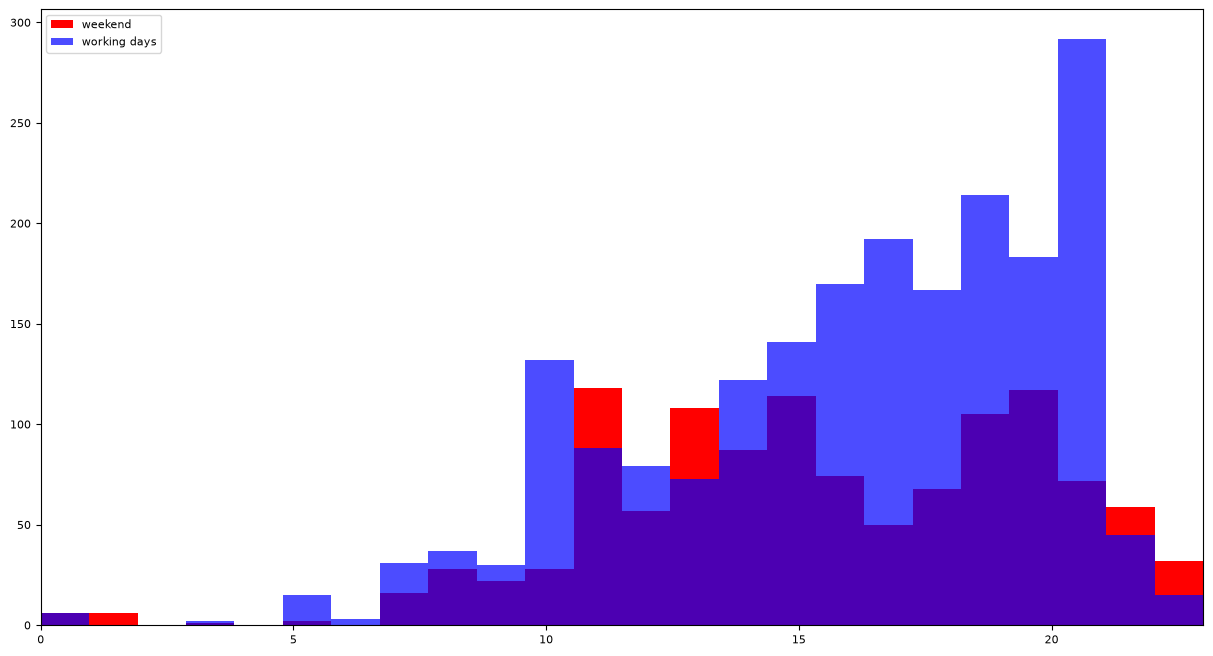

In [59]:
plt.figure(figsize=(15, 8))
plt.rcParams['font.size'] = 8
plt.hist(weekend_commits['hour'], bins=24, color='red', label='weekend')
plt.hist(workdays_commits['hour'],alpha=0.7, bins=24, color='blue', label='working days')
plt.legend()
plt.xlim(0, 23)

Есть ли часы, когда общее число коммитов было выше в выходные, чем в рабочие дни?» В ответе приведи топ-4 примера.
Да, есть 11, 13, 22, 23